In [29]:
import aare
from aare import transform #Needed to read Matterhorn 1.0 datra

import time
import numpy as np
import matplotlib.pyplot as plt
import boost_histogram as bh # Fast histogram
from pathlib import Path

#Read/write compressed hdf5
import hdf5plugin
import h5py

## Gauss

In [2]:
#Generate 256x256 pixels with gaussian data
t0 = time.perf_counter()
n_bins = 50
n_rows = 256
n_cols = 256
n_samples = 1000

data = np.zeros((n_rows, n_cols, n_bins))

for i in range(n_rows):
    for j in range(n_cols):
        h = bh.Histogram(bh.axis.Regular(50, 0, 10))
        h.fill(np.random.normal(loc=np.random.normal(4), scale=1.0, size=n_samples))
        data[i,j] = h.values()
        x = h.axes[0].centers

t = time.perf_counter()-t0
print(f'{t:.3f}s')


4.370s


### Fit one pixel

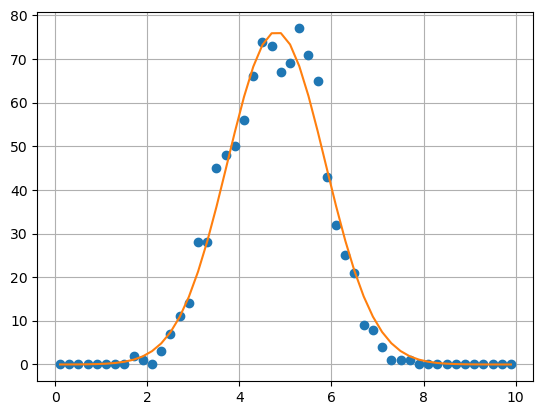

In [9]:
#Fit one pixel
pixel = (120,36)
model = aare.Gaussian()
y = data[*pixel]

res = aare.fit(model, x, y)
xx = np.linspace(x[0], x[-1])
yy = model(xx, res['par'])

fig, ax = plt.subplots()
ax.plot(x,y, 'o')
ax.plot(xx, yy)
ax.grid()

### Fix Parameter/ Parameter range

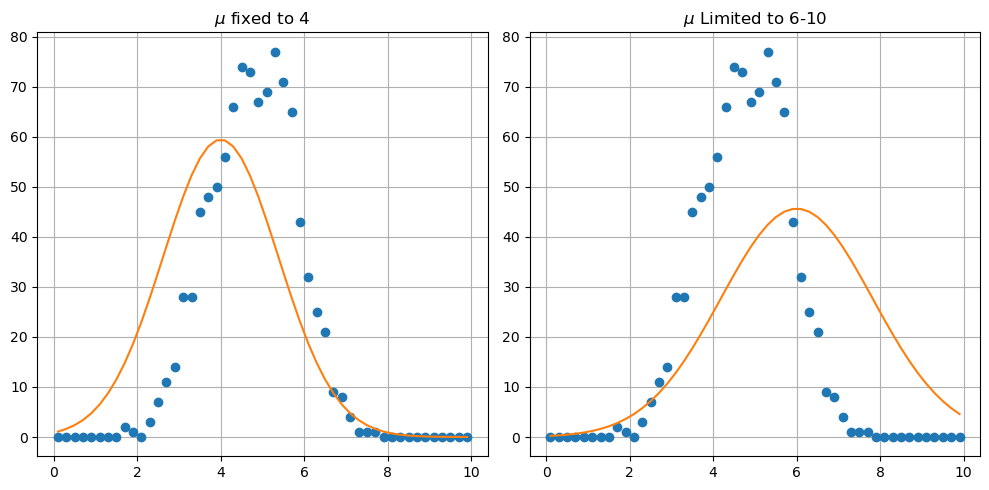

In [17]:
#Fit one pixel fix parameter
pixel = (120,36)
model = aare.Gaussian()
model.FixParameter(1,4)
y = data[*pixel]

res = aare.fit(model, x, y)
xx = np.linspace(x[0], x[-1])
yy = model(xx, res['par'])

fig, axs = plt.subplots(1,2, figsize = (10,5))
axs[0].plot(x,y, 'o')
axs[0].plot(xx, yy)
axs[0].grid()
axs[0].set_title(r'$\mu$ fixed to 4')

model = aare.Gaussian()
model.SetParLimits(1,6,10)
res = aare.fit(model, x, y)
xx = np.linspace(x[0], x[-1])
yy = model(xx, res['par'])
axs[1].plot(x,y, 'o')
axs[1].plot(xx, yy)
axs[1].grid()
axs[1].set_title(r'$\mu$ Limited to 6-10')
fig.tight_layout()

### Fit all pixels

- By passing x, data[row, col, frame] it's possible to run fits in parallel

In [27]:
t0 = time.perf_counter()
model = aare.Gaussian()
res = aare.fit(model, x, data, n_threads = 32)
t = time.perf_counter()-t0
print(fr'Fit took: {t:.3f}s or {t/256**2*1e6:.3f} us per pixel')

Fit took: 0.050s or 0.764 us per pixel


## s-curves (FallingScurve/RisingScurve)

In [30]:

path = Path('/mnt/sls_det_storage/gorner_data/MH10_tests/')
fname = path/'0325_Vrf990_xctb4_bigXrayCu_master_0.json'


t = transform.Matterhorn10Transform(16,4)
x = np.arange(2000,3500,20) #Thresholds not in file

with aare.CtbRawFile(fname, transform = t) as f:
    header, data = f.read()

# Data is written to file as [frame, row, col] we need 
# [row, col, frame] to optimize fitting
data = data.transpose(1,2,0)

#Select steps with th larger than 2200 to avoid the noise peak
mask = (x>2200) & (x<5000)
x = x[mask]
xx = np.linspace(x[0], x[-1])
data = data[:,:,mask]
print(f'{data.shape=}, {x.shape=}')

data.shape=(1024, 256, 64), x.shape=(64,)


In [33]:
t0 = time.perf_counter()
model = aare.FallingScurve()
# model.FixParameter(1,0)
res = aare.fit(model, x, data, n_threads = 32)
t = time.perf_counter()-t0
print(f'Fit took: {t:.3f}s or {t/(1024*256)*1e6:.3f} us per pixel')

Fit took: 2.443s or 9.319 us per pixel


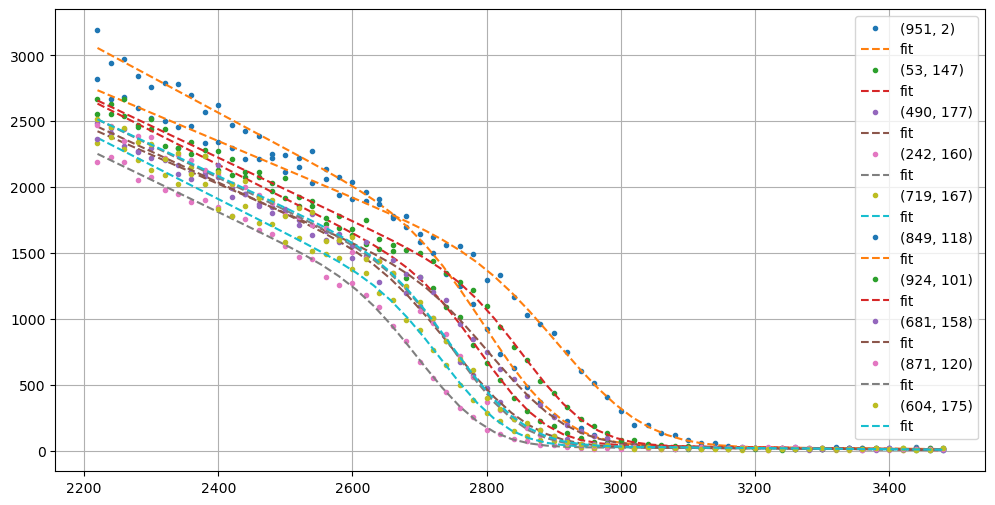

In [36]:
pixels = aare.random_pixels(xmin = 0, xmax = 256, ymin = 0, ymax = 1024, n_pixels = 10)
fig, ax = plt.subplots(figsize = (12,6))
for pixel in pixels:
    y = data[*pixel].copy()
    ax.plot(x, y, label = f'{pixel}', lw = 0, marker = '.')
    yy = model(xx,res['par'][*pixel])
    ax.plot(xx,yy, '--', label = 'fit')
ax.legend()
ax.grid()